# Customer Analysis

This notebook analyzes customer behavior in the Olist e-commerce dataset using PostgreSQL.

The analysis focuses on:

- Customer distribution by state
- Most purchased product categories
- Average order value by state
- Credit card payment frequency
- Use of multiple installments

All analytical calculations are performed in SQL, while Python is used for data retrieval and visualization.

In [28]:
import getpass
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, URL

password = getpass.getpass("PostgreSQL password: ")

connection_url = URL.create(
    "postgresql+psycopg2",
    username="laraolgun",
    password=password,
    host="localhost",
    database="olist"
)

engine = create_engine(connection_url)

print("Connected to PostgreSQL: olist")

Connected to PostgreSQL: olist


## 1. Unique Customers by State

In [29]:
query = """
SELECT
    customer_state,
    COUNT(DISTINCT customer_unique_id) AS no_of_customers
FROM customers
GROUP BY customer_state
ORDER BY no_of_customers DESC;
"""

df_customers_state = pd.read_sql_query(query, engine)

df_customers_state

,customer_state,no_of_customers
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


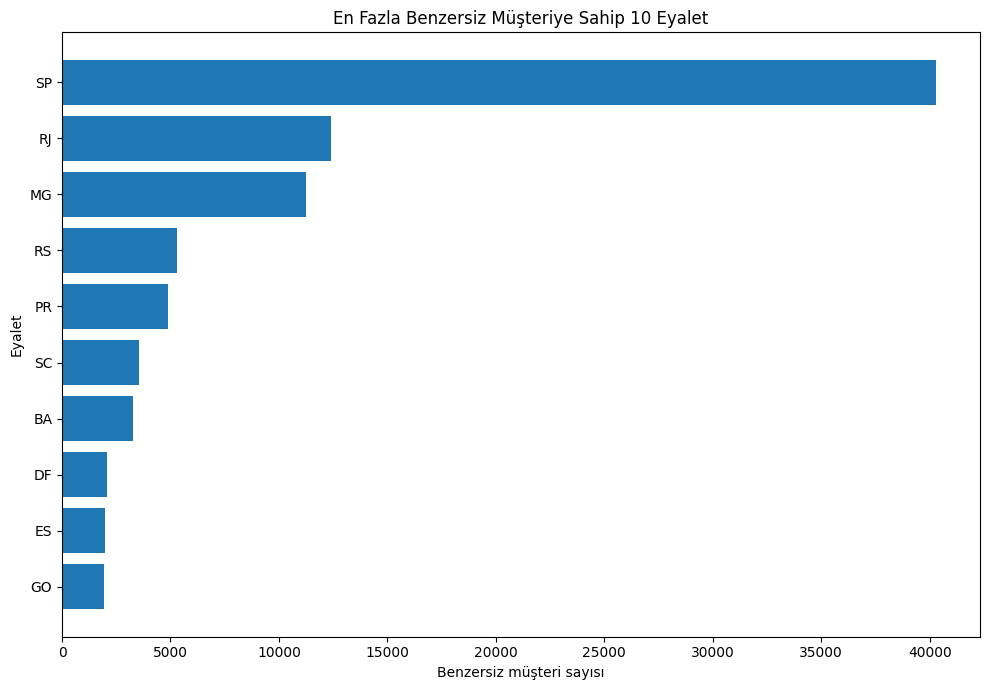

In [30]:
plt.figure(figsize=(10, 7))

plt.barh(
    df_customers_state["customer_state"].head(10)[::-1],
    df_customers_state["no_of_customers"].head(10)[::-1]
)

plt.xlabel("Benzersiz müşteri sayısı")
plt.ylabel("Eyalet")
plt.title("En Fazla Benzersiz Müşteriye Sahip 10 Eyalet")

plt.tight_layout()
plt.show()

## 2. Top 10 Product Categories by Units Sold

In [31]:
query = """
SELECT
    p.product_category,
    COUNT(*) AS units_sold
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
JOIN orders o
    ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
  AND p.product_category IS NOT NULL
GROUP BY p.product_category
ORDER BY units_sold DESC
LIMIT 10;
"""

df_top_categories = pd.read_sql_query(query, engine)

df_top_categories

,product_category,units_sold
0,cama_mesa_banho,10953
1,beleza_saude,9465
2,esporte_lazer,8431
3,moveis_decoracao,8160
4,informatica_acessorios,7644
5,utilidades_domesticas,6795
6,relogios_presentes,5859
7,telefonia,4430
8,ferramentas_jardim,4268
9,automotivo,4140


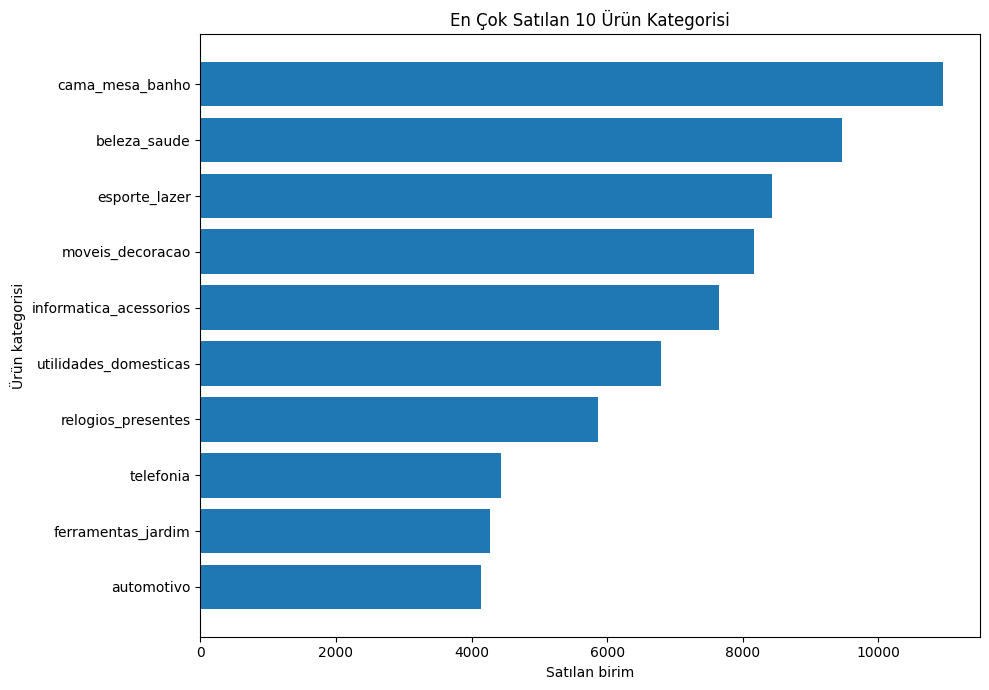

In [32]:
plt.figure(figsize=(10, 7))

plt.barh(
    df_top_categories["product_category"][::-1],
    df_top_categories["units_sold"][::-1]
)

plt.xlabel("Satılan birim")
plt.ylabel("Ürün kategorisi")
plt.title("En Çok Satılan 10 Ürün Kategorisi")

plt.tight_layout()
plt.show()

## 3. Average Order Value by State

In [33]:
query = """
WITH order_totals AS (
    SELECT
        o.order_id,
        c.customer_state,
        SUM(oi.price + oi.freight_value) AS order_value
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY o.order_id, c.customer_state
)
SELECT
    customer_state,
    COUNT(*) AS delivered_orders,
    ROUND(AVG(order_value)::numeric, 2) AS avg_order_value
FROM order_totals
GROUP BY customer_state
ORDER BY avg_order_value DESC;
"""

df_avg_order_value = pd.read_sql_query(query, engine)

df_avg_order_value

,customer_state,delivered_orders,avg_order_value
0,PB,517,266.61
1,AC,80,244.69
2,AP,67,240.92
3,AL,397,237.21
4,RO,243,234.43
5,PA,946,224.13
6,PI,476,220.96
7,RR,41,220.48
8,TO,274,219.00
9,RN,474,212.48


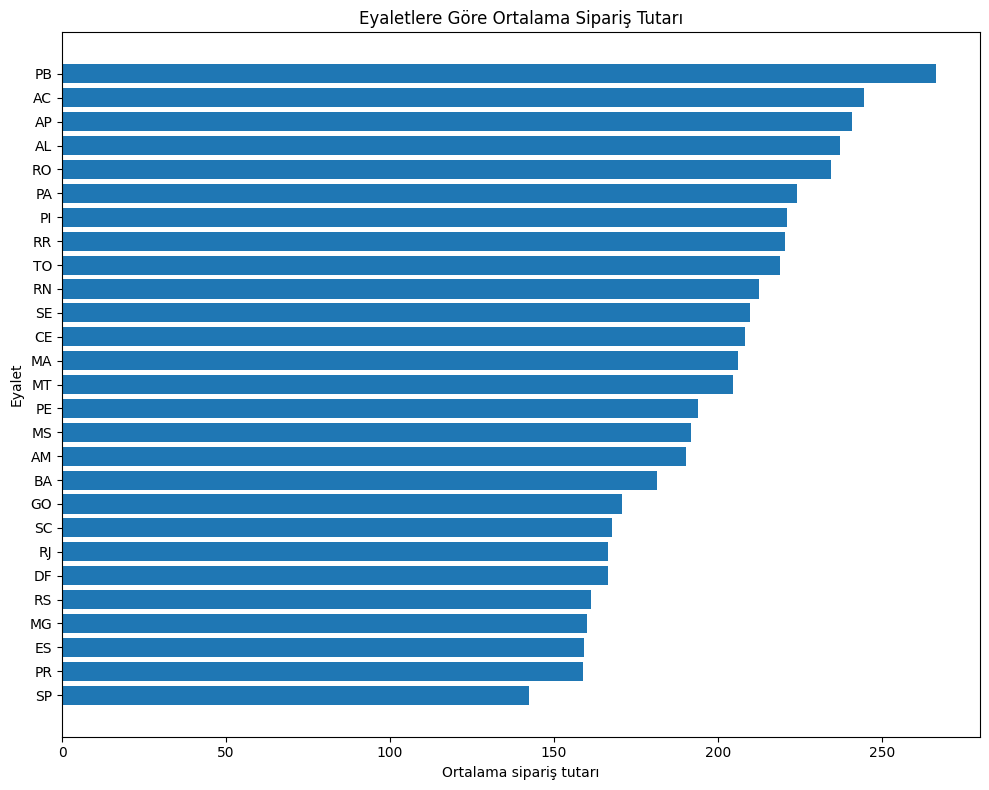

In [34]:
plt.figure(figsize=(10, 8))

plt.barh(
    df_avg_order_value["customer_state"][::-1],
    df_avg_order_value["avg_order_value"][::-1]
)

plt.xlabel("Ortalama sipariş tutarı")
plt.ylabel("Eyalet")
plt.title("Eyaletlere Göre Ortalama Sipariş Tutarı")

plt.tight_layout()
plt.show()

## 4. Credit Card Payment Frequency by State

In [35]:
query = """
SELECT
    c.customer_state,
    COUNT(*) AS credit_card_payments
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN order_payments op
    ON o.order_id = op.order_id
WHERE op.payment_type = 'credit_card'
GROUP BY c.customer_state
ORDER BY credit_card_payments DESC;
"""

df_credit_card = pd.read_sql_query(query, engine)

df_credit_card

,customer_state,credit_card_payments
0,SP,32168
1,RJ,10288
2,MG,9070
3,RS,3985
4,PR,3786
5,SC,2713
6,BA,2662
7,DF,1700
8,ES,1573
9,GO,1520


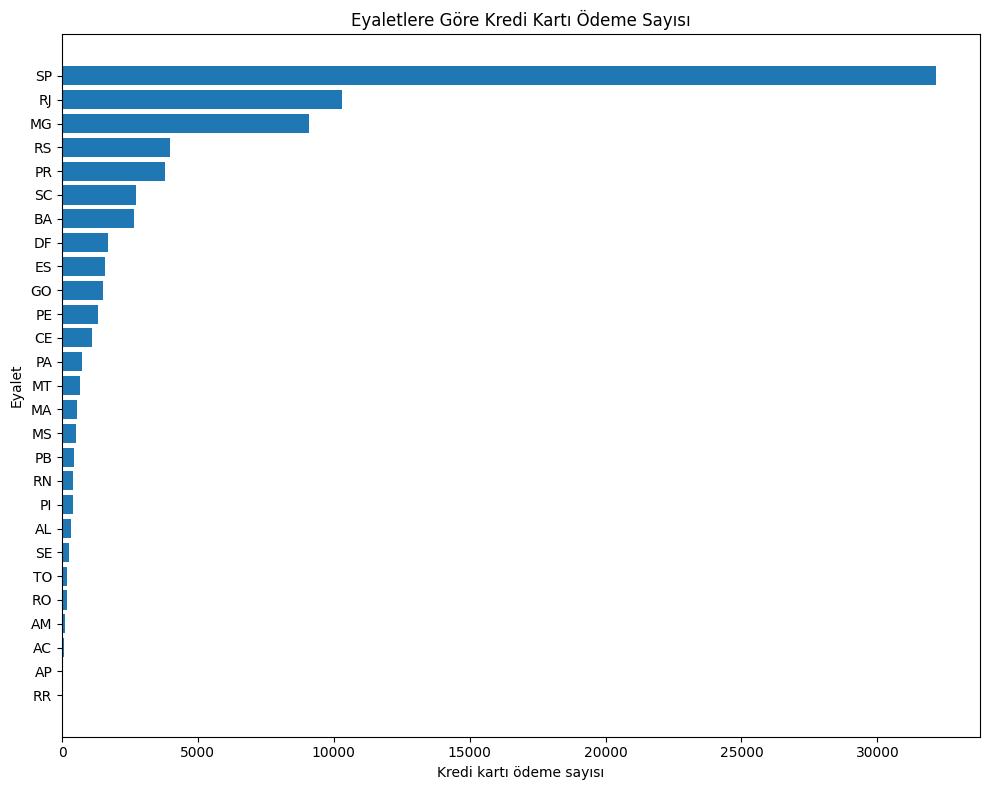

In [36]:
plt.figure(figsize=(10, 8))

plt.barh(
    df_credit_card["customer_state"][::-1],
    df_credit_card["credit_card_payments"][::-1]
)

plt.xlabel("Kredi kartı ödeme sayısı")
plt.ylabel("Eyalet")
plt.title("Eyaletlere Göre Kredi Kartı Ödeme Sayısı")

plt.tight_layout()
plt.show()

## 5. Customers Using Multiple Installments by State

In [37]:
query = """
WITH customer_payments AS (
    SELECT
        c.customer_unique_id,
        c.customer_state,
        MAX(op.payment_installments) AS max_installments
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    JOIN order_payments op
        ON o.order_id = op.order_id
    GROUP BY c.customer_unique_id, c.customer_state
)
SELECT
    customer_state,
    COUNT(*) AS customers,
    COUNT(*) FILTER (WHERE max_installments > 1) AS customers_multiple_installments,
    ROUND(
        100.0 * COUNT(*) FILTER (WHERE max_installments > 1) / COUNT(*),
        2
    ) AS proportion_percent
FROM customer_payments
GROUP BY customer_state
ORDER BY proportion_percent DESC;
"""

df_installments = pd.read_sql_query(query, engine)

df_installments

,customer_state,customers,customers_multiple_installments,proportion_percent
0,AL,401,265,66.08
1,AC,77,50,64.94
2,RN,474,306,64.56
3,PB,519,334,64.35
4,PE,1609,1011,62.83
5,CE,1313,825,62.83
6,PI,482,291,60.37
7,SE,342,206,60.23
8,RO,240,141,58.75
9,BA,3277,1910,58.29


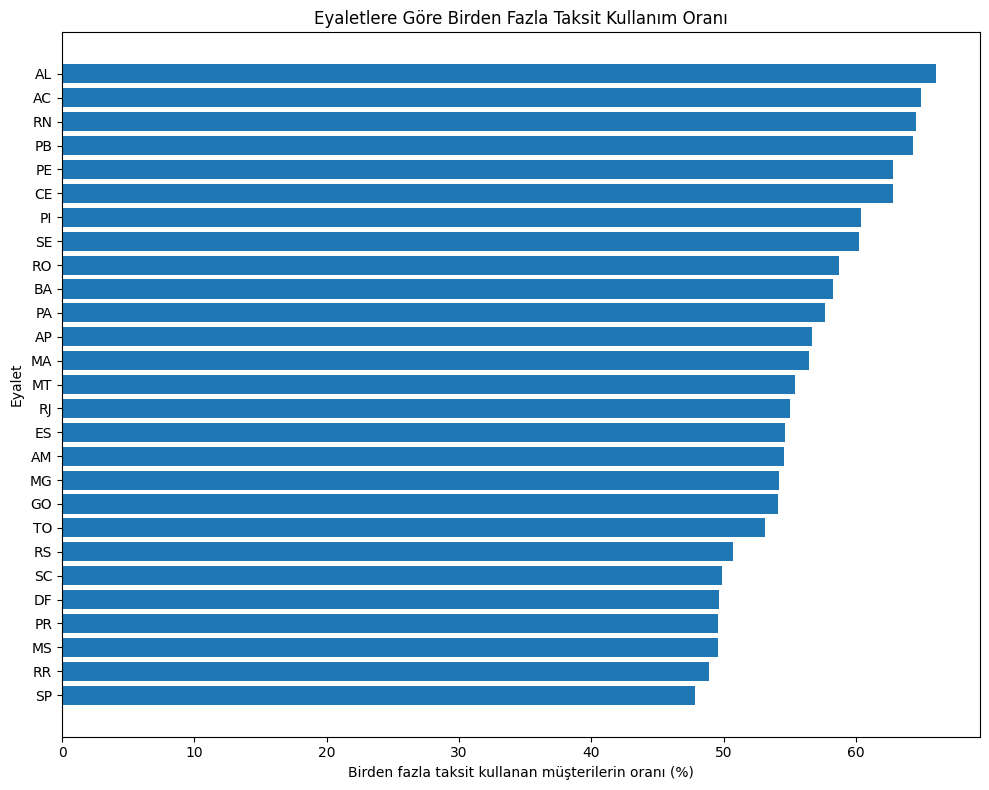

In [38]:
plt.figure(figsize=(10, 8))

plt.barh(
    df_installments["customer_state"][::-1],
    df_installments["proportion_percent"][::-1]
)

plt.xlabel("Birden fazla taksit kullanan müşterilerin oranı (%)")
plt.ylabel("Eyalet")
plt.title("Eyaletlere Göre Birden Fazla Taksit Kullanım Oranı")

plt.tight_layout()
plt.show()

In [39]:
engine.dispose()